In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)


In [16]:

import kagglehub
import os

path = kagglehub.dataset_download("bhargavchirumamilla/netflix-movies-and-tv-shows-till-2025")

print("Path to dataset files:", path)

files = os.listdir(path)
print("Files:", files)

#Load the CSV into a DataFrame
csv_file = [f for f in files if f.endswith('.csv')][0]

df = pd.read_csv(os.path.join(path, csv_file))

#Explore the data
print(df.shape)        # rows and columns
print(df.head())       # first 5 rows
print(df.dtypes)       # column types
print(df.isnull().sum()) # missing values



Using Colab cache for faster access to the 'netflix-movies-and-tv-shows-till-2025' dataset.
Path to dataset files: /kaggle/input/netflix-movies-and-tv-shows-till-2025
Files: ['netflix_movies_detailed_up_to_2025.csv', 'netflix_tv_shows_detailed_up_to_2025.csv']
(16000, 18)
   show_id   type                                         title  \
0    10192  Movie                           Shrek Forever After   
1    27205  Movie                                     Inception   
2    12444  Movie  Harry Potter and the Deathly Hallows: Part 1   
3    38757  Movie                                       Tangled   
4    10191  Movie                      How to Train Your Dragon   

                      director  \
0                Mike Mitchell   
1            Christopher Nolan   
2                  David Yates   
3   Byron Howard, Nathan Greno   
4  Chris Sanders, Dean DeBlois   

                                                cast  \
0  Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...   
1  Leon

In [17]:
# Add features to data frame
##########################
df = df.dropna(subset=['rating', 'release_year', 'genres', 'description'])
df = df[df['rating'] > 0]
##########################

# Encode type
df['is_tv'] = (df['type'].astype(str) == 'TV Show').astype(int)
df['desc_length'] = df['description'].fillna('').apply(lambda x: len(x.split()))

# Extract date features
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['added_year'] = df['date_added'].dt.year.fillna(0).astype(int)
df['added_month'] = df['date_added'].dt.month.fillna(0).astype(int)


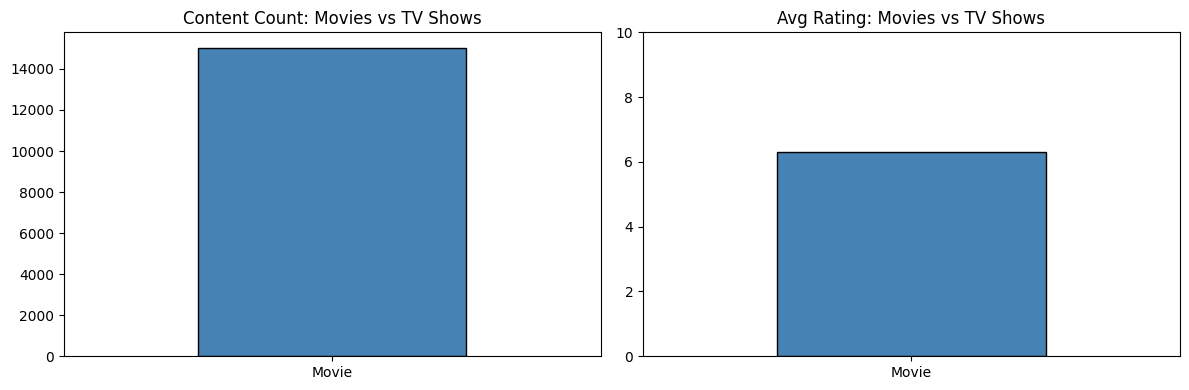

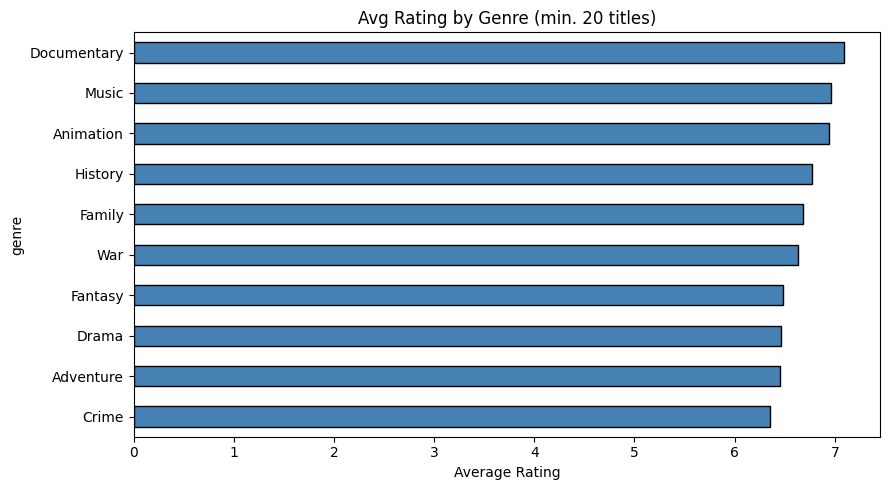

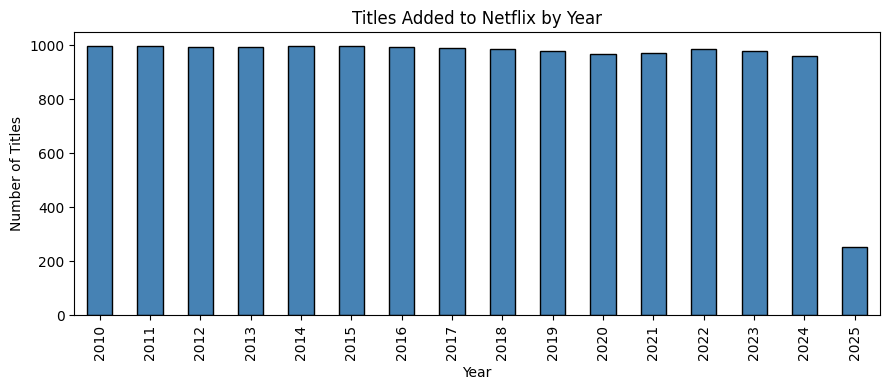

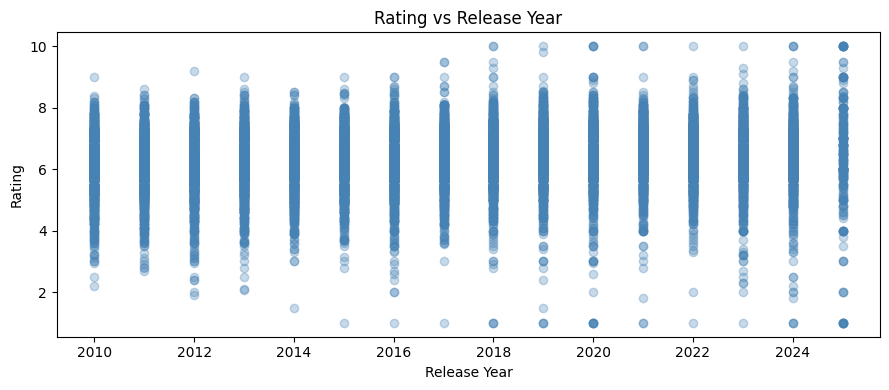

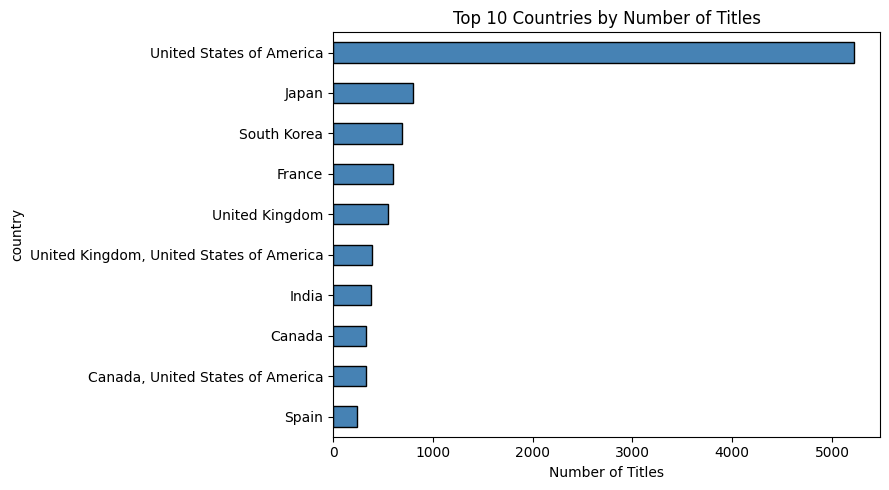

In [18]:

#Movies vs TV Shows — count and avg rating
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['type'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title("Content Count: Movies vs TV Shows")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=0)

df.groupby('type')['rating'].mean().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title("Avg Rating: Movies vs TV Shows")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

# Average Rating by Top 10 Genres
genre_ratings = (
    df.assign(genre=df['genres'].str.split(', '))
    .explode('genre')
    .groupby('genre')['rating']
    .agg(['mean', 'count'])
    .query('count >= 20')          # filter out genres with very few titles
    .sort_values('mean', ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
genre_ratings['mean'].sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Avg Rating by Genre (min. 20 titles)")
plt.xlabel("Average Rating")
plt.tight_layout()
plt.show()

# Content Added to Netflix Over Time
plt.figure(figsize=(9, 4))
df.groupby('added_year')['rating'].count().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Titles Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

# Rating vs Release Year (scatter)
plt.figure(figsize=(9, 4))
plt.scatter(df['release_year'], df['rating'], alpha=0.3, color='steelblue')
plt.title("Rating vs Release Year")
plt.xlabel("Release Year")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

# Top 10 Countries by Content Count
top_country_counts = (
    df['country'].dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(9, 5))
top_country_counts.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.show()

In [19]:
# Top 15 genres
top_genres = df['genres'].str.split(', ').explode().value_counts().head(15).index
for genre in top_genres:
    df[f'genre_{genre}'] = df['genres'].str.contains(genre, na=False).astype(int)

# Top 10 languages
top_langs = df['language'].dropna().value_counts().head(10).index
for lang in top_langs:
    df[f'lang_{lang}'] = (df['language'] == lang).astype(int)

# Top 50 actors
top_actors = df['cast'].dropna().str.split(', ').explode().value_counts().head(50).index
for actor in top_actors:
    df[f'actor_{actor}'] = df['cast'].str.contains(actor, na=False).astype(int)

# Top 40 directors
top_directors = df['director'].dropna().value_counts().head(40).index
for director in top_directors:
    df[f'director_{director}'] = df['director'].str.contains(director, na=False).astype(int)

# Top 15 countries
top_countries = df['country'].dropna().value_counts().head(15).index
for country in top_countries:
    df[f'country_{country}'] = df['country'].str.contains(country, na=False).astype(int)

df = df.copy()



In [20]:
feature_cols = [
    'is_tv', 'release_year', 'popularity', 'vote_count',
    'added_year', 'added_month', 'desc_length'
] + [f'genre_{g}' for g in top_genres] \
  + [f'lang_{l}' for l in top_langs] \
  + [f'actor_{a}' for a in top_actors] \
  + [f'director_{d}' for d in top_directors] \
  + [f'country_{c}' for c in top_countries]


##########################
X = df[feature_cols]
y = df['rating']
##########################

In [21]:
tfidf = TfidfVectorizer(max_features=300, stop_words='english',
                        ngram_range=(1, 2))
desc_features = tfidf.fit_transform(df['description'].fillna(''))

# Combine structured features with TF-IDF features

##########################
X_combined = sp.hstack([sp.csr_matrix(X.values), desc_features])
##########################

In [22]:
# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0]
}

search = RandomizedSearchCV(XGBRegressor(random_state=42), param_grid,
                            n_iter=20, cv=3, scoring='r2', random_state=42)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV R²:", search.best_score_)

best_trained_model = search.best_estimator_
best_model_name = "XGBoost (Tuned)"

# Compare with Random Forest
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

xgb_pred = best_trained_model.predict(X_test)

results = {
    "Random Forest": {
        "MAE": mean_absolute_error(y_test, rf_pred),
        "R²": r2_score(y_test, rf_pred)
    },
    "XGBoost (Tuned)": {
        "MAE": mean_absolute_error(y_test, xgb_pred),
        "R²": r2_score(y_test, xgb_pred)
    }
}
print(pd.DataFrame(results).T)

# Cross-Validation on Tuned Model
cv_scores = cross_val_score(best_trained_model, X_combined, y, cv=5, scoring='r2')
print(f"\nCV R² (mean ± std) for {best_model_name}: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Final Evaluation
y_pred_best = best_trained_model.predict(X_test)
print(f"\nFinal MAE:  {mean_absolute_error(y_test, y_pred_best):.3f}")
print(f"Final R²:   {r2_score(y_test, y_pred_best):.3f}")

Best params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05}
Best CV R²: 0.38062055549709345
                      MAE        R²
Random Forest    0.561391  0.371635
XGBoost (Tuned)  0.561044  0.387499

CV R² (mean ± std) for XGBoost (Tuned): 0.369 ± 0.107

Final MAE:  0.561
Final R²:   0.387


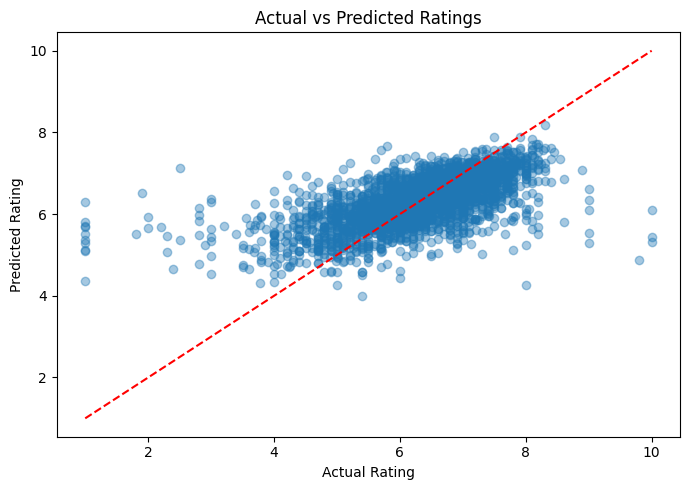

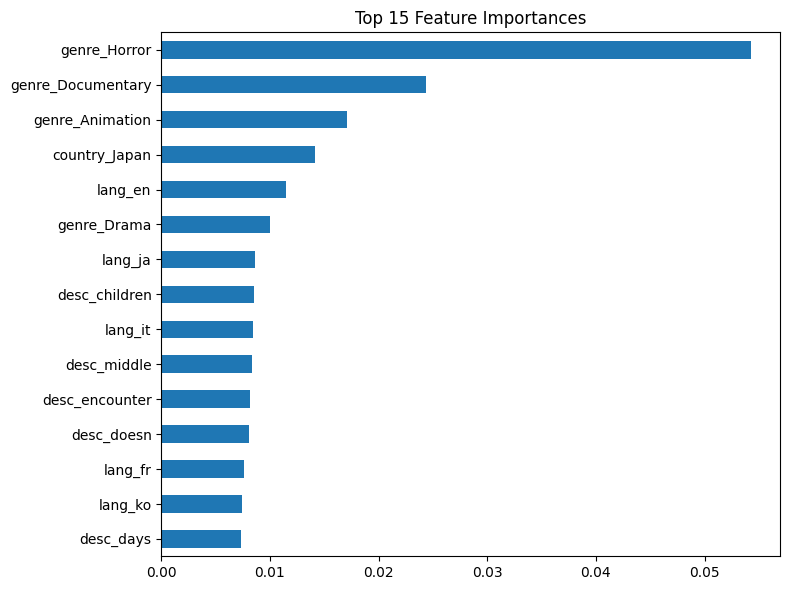

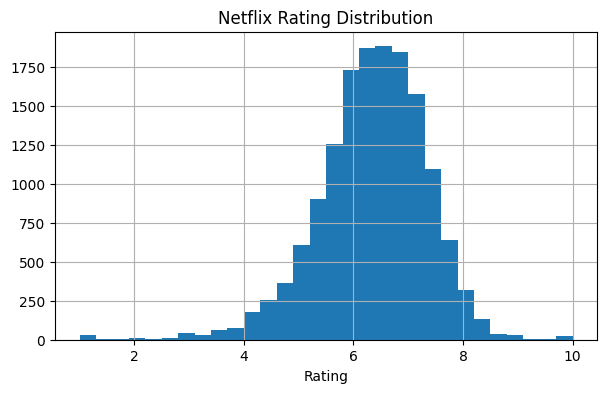

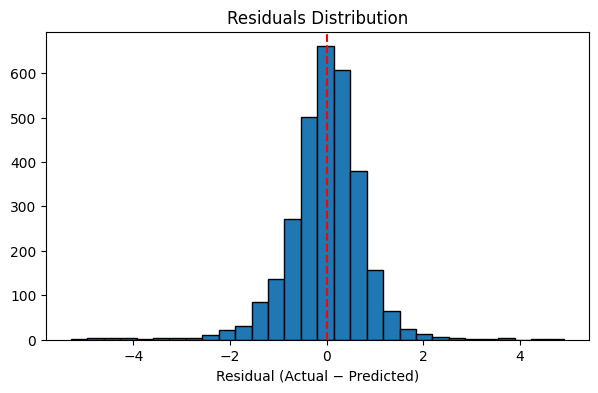

In [23]:
# 1. Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.tight_layout()
plt.show()

# 2. Top Feature Importances (XGBoost gives these for free)
tfidf_names = [f'desc_{w}' for w in tfidf.get_feature_names_out()]
feature_col_names = feature_cols + tfidf_names
importances = pd.Series(best_trained_model.feature_importances_, index=feature_col_names)  # ← missing
importances.nlargest(15).sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

# 3. Rating Distribution
df['rating'].hist(bins=30, figsize=(7, 4))
plt.title("Netflix Rating Distribution")
plt.xlabel("Rating")
plt.show()

residuals = y_test - y_pred_best
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual − Predicted)")
plt.show()